## SNOTEL QC Development
Evaluate some approaches to doing QC on SNOTEL data.

In [1]:
%matplotlib ipympl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, date, time
from buildforcing.datasets import PNNLSnotel
import os

In [37]:
site = 'Baldy'

In [ ]:
# Alpine Environmental Vars
os.environ['SNOTEL_PATH'] = '/projects/ccox1@xsede.org/data/snotel'
os.environ['NLDAS_PATH'] = '/projects/ccox1@xsede.org/data/nldas'


### Load Data
I only care about the range of data used in the downscaling, so I'll limit the data to that range using the find_usable_dates function from buildforcing.

In [38]:
snotel = PNNLSnotel(site_name=site, storage_path=os.environ['SNOTEL_PATH'])
snotel.load_data()

# print latitude and longitude for reference
print(f"Latitude: {snotel.latitude}, Longitude: {snotel.longitude}")

Latitude: 33.98, Longitude: -109.5


In [39]:
start_date, end_date = snotel.find_usable_dates()
print(f"Usable dates: {start_date} to {end_date}")

Usable dates: 1988-09-27 to 2021-09-30


In [40]:
# Extract SNOTEL data for the usable date range or starting in 1990, whichever is later
if start_date < date(1990, 1, 1):
    start_date = date(1990, 1, 1)

snotel_data = snotel.data[start_date.strftime('%Y-%m-%d'):end_date.strftime('%Y-%m-%d')]

I think most of the datasets are daily with Nans for missing data, but it seems reasonable to ensure that is the case.

In [41]:
# Ensure index is daily
snotel_data = snotel_data.asfreq('D')

Load some raw data for comparison if needed.

In [54]:
# Load specific raw data
#raw_data = pd.read_csv('C:/Users/clmbn/NMT_PhD/data/snotel/raw_selected/Baldy_T_1993.csv', parse_dates=['Date'], index_col='Date', skiprows=6)
# Load raw data from path using coordinates
raw_data_path = os.path.join(os.environ['SNOTEL_PATH'], f'raw_data/raw_{snotel.latitude:.5f}_{snotel.longitude:.5f}.txt')
# Read the raw data using whitespace as separator
raw_data = pd.read_csv(raw_data_path, sep=r'\s+', header=None,
                      names=['Year', 'Month', 'Day', 'Precip_accum', 'Precip_daily', 'Tmax', 'Tmin', 'Tavg', 'SWE'],
                      na_values='nan')

In [55]:
# Convert the year, month, and day columns to a datetime index
raw_data['Date'] = pd.to_datetime(raw_data[['Year', 'Month', 'Day']])
raw_data.set_index('Date', inplace=True)

In [56]:
raw_max_temp = raw_data.loc[start_date:end_date, 'Tmax']

#### Visualization

In [42]:
# Calculate F temperatures for easier analysis
snotel_data['T_max_F'] = snotel_data['T_max_C'] * 9/5 + 32
snotel_data['T_min_F'] = snotel_data['T_min_C'] * 9/5 + 32
snotel_data['T_avg_F'] = snotel_data['T_avg_C'] * 9/5 + 32

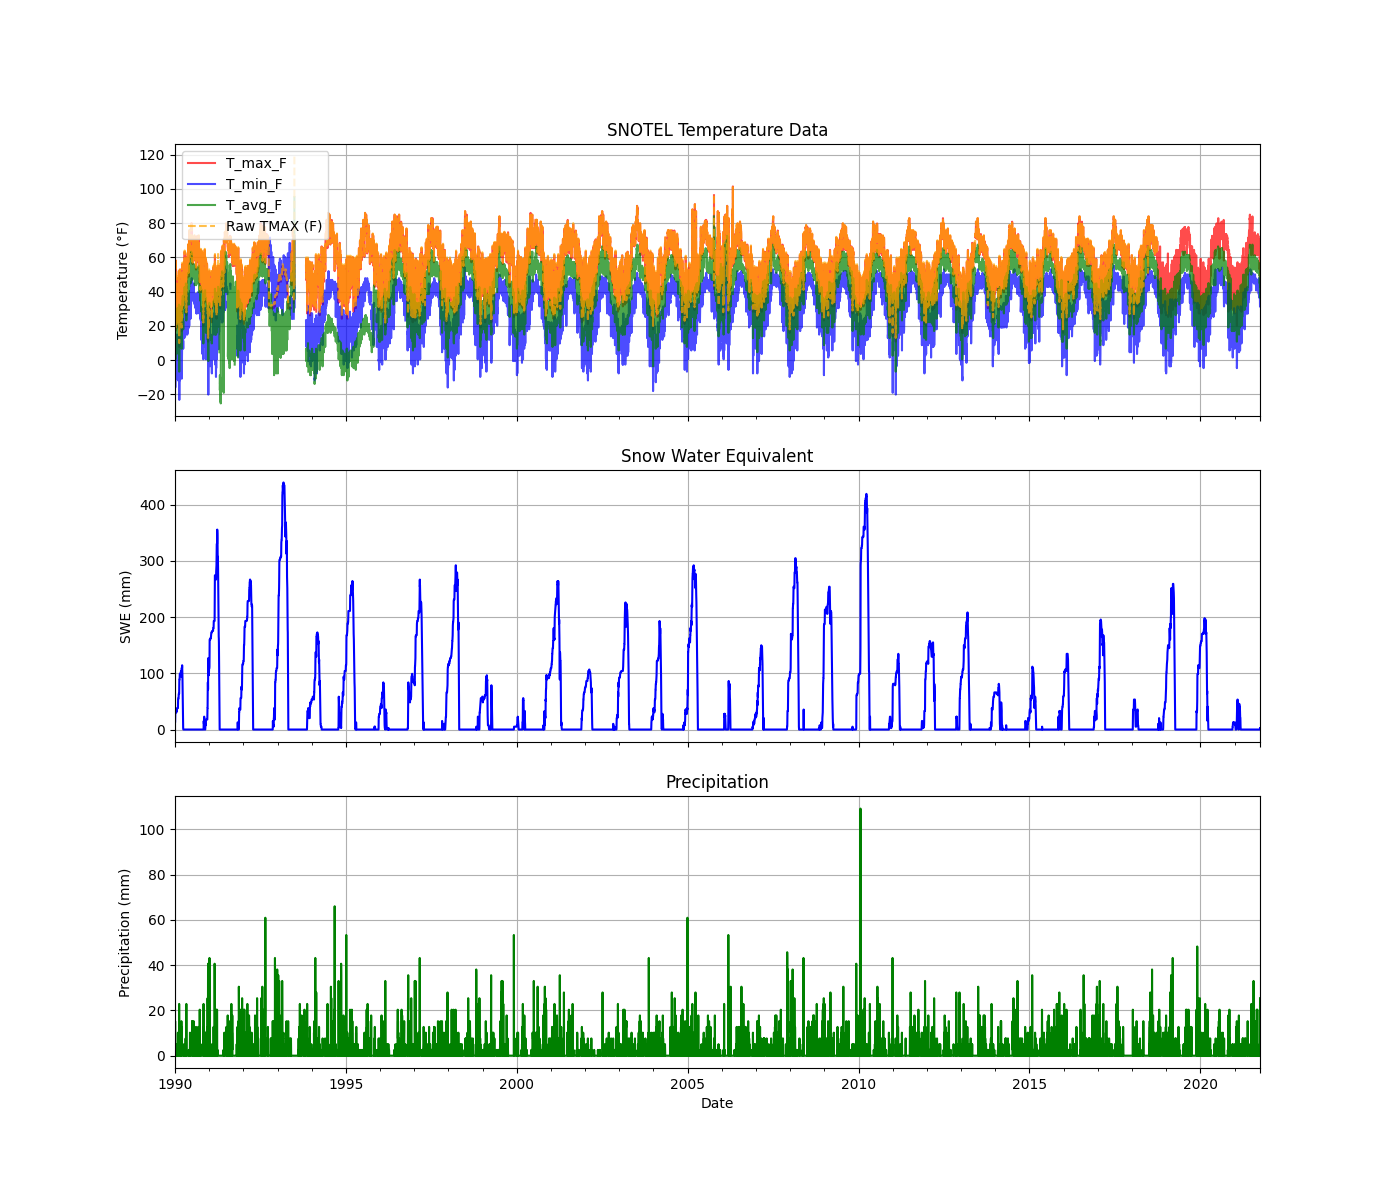

In [57]:
# Create a single figure with 3 subplots (temperature, SWE, precipitation)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot temperatures in the top subplot
snotel_data['T_max_F'].plot(ax=ax1, label='T_max_F', color='red', alpha=0.7)
snotel_data['T_min_F'].plot(ax=ax1, label='T_min_F', color='blue', alpha=0.7)
snotel_data['T_avg_F'].plot(ax=ax1, label='T_avg_F', color='green', alpha=0.7)
raw_max_temp.plot(ax=ax1, label='Raw TMAX (F)', color='orange', linestyle='--', alpha=0.7)
ax1.set_ylabel('Temperature (°F)')
ax1.set_title('SNOTEL Temperature Data')
ax1.legend()
ax1.grid(True)

# Plot SWE in the middle subplot
ax2.plot(snotel_data.index, snotel_data['swe_mm'], color='blue')
ax2.set_ylabel('SWE (mm)')
ax2.set_title('Snow Water Equivalent')
ax2.grid(True)

# Plot Precipitation in the bottom subplot
ax3.plot(snotel_data.index, snotel_data['precip_mm'], color='green')
ax3.set_xlabel('Date')
ax3.set_ylabel('Precipitation (mm)')
ax3.set_title('Precipitation')
ax3.grid(True)

plt.show()

## QC Testing

Extract sections of interest for manual review.

In [ ]:
test_start = '2004-01-01'
test_end = '2007-12-31'
test_section = snotel_data.loc[test_start:test_end, ['T_max_C', 'T_min_C', 'T_avg_C']]

In [ ]:
from buildforcing import snotelQC
from buildforcing.datasets import siteNLDAS

Flag test data

In [ ]:
test_flags = snotelQC.qc_maxmin_temperatures(test_section[['T_max_C', 'T_min_C']], outlier_std=2.5)

In [ ]:
# Create series of clean data
snotel_Tmax_clean = test_section['T_max_C'].where(~test_flags['Tmax_bad'])
snotel_Tmin_clean = test_section['T_min_C'].where(~test_flags['Tmin_bad'])

Fill data using NLDAS

In [ ]:
nldas_data = siteNLDAS(snotel.latitude, snotel.longitude, start_date=datetime.strptime(test_start, '%Y-%m-%d'), end_date=datetime.strptime(test_end, '%Y-%m-%d'))

In [ ]:
nldas_data.loadNetCDF(os.environ['NLDAS_PATH'])

In [ ]:
nldas_data.data.tail()

In [ ]:
# Generate filled data for comparison
snotel_Tmax_filled = snotelQC.fill_T_nldas(snotel_Tmax_clean, nldas_T_data=nldas_data.data['Tair'])
snotel_Tmin_filled = snotelQC.fill_T_nldas(snotel_Tmin_clean, nldas_T_data=nldas_data.data['Tair'])

In [ ]:
# Plot test section with flags and clean data in two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot test section with flags in the top subplot
test_section['T_max_C'].plot(ax=ax1, label='T_max_C', color='red', alpha=0.7)
test_section['T_min_C'].plot(ax=ax1, label='T_min_C', color='blue', alpha=0.7)
ax1.scatter(test_section.index[test_flags['Tmax_bad']], test_section['T_max_C'][test_flags['Tmax_bad']], color='black', marker='x', s=100, label='Tmax Bad Flag')
ax1.scatter(test_section.index[test_flags['Tmin_bad']], test_section['T_min_C'][test_flags['Tmin_bad']], color='orange', marker='x', s=100, label='Tmin Bad Flag')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Data with Flags')
ax1.legend()
ax1.grid(True)

# Plot clean data in the bottom subplot
snotel_Tmax_filled.plot(ax=ax2, label='T_max_C', color='red', alpha=0.7)
snotel_Tmin_filled.plot(ax=ax2, label='T_min_C', color='blue', alpha=0.7)
ax2.set_ylabel('Temperature (°C)')
ax2.set_xlabel('Date')
ax2.set_title('Clean Temperature Data (Flags Removed)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()